# Agregando multiples elementos quimicos ademas de traquear los elementos.

In [1]:
from tripodpy import Simulation
import numpy as np
import dustpy.constants as c
import matplotlib.pyplot as plt

In [2]:
sim = Simulation()
sim.ini.grid.Nr = 500
sim.initialize()

In [3]:
data = np.genfromtxt(
    'chem.txt',
    dtype=None,     # Automatically determine data types
    names=True,     # Use first non-skipped line as column names
    encoding='utf-8',  # Handle text encoding
    usecols=(0, 1, 2, 3, 4, 5),  # Specify columns to read
    comments='#'    # Skip lines starting with #
)

#print the text file
with open('chem.txt', 'r', encoding='utf-8') as f:
    print(f.read())

# Species Abundance nu_des T_bind mu p_stick  Ref
H2O       1.6e-4   4.0e13 5800    16  1.0      Fraser_2001
CO2       4.0e-5   1.0e13 2700    44  1.0      Sandford_1990
CO        8.0e-5   7.0e11 1180    28  1.0      Fayolle_2016
CH4       0.0e-0   -1     1250    16  1.0      Penteado_2017
C2H6      1.5e-5   6.0e16 2500    30  1.0      Behmard_2019
CH3OH     0.0e-0   -1     4930    32  1.0      Penteado_2017
N2        3.0e-5   8.0e11 1050    28  1.0      Fayolle_2016
NH3       7.0e-6   1.0e13 3800    17  1.0      Suhasaria_2015
He        9.5e-2   -1     100     4   1.0      Penteado_2017
Ar        2.5e-6   6.0e11 870     40  1.0      Smith_2016
Kr        1.8e-9   1.2e14 1380    83  1.0      Smith_2016
Xe        1.7e-10  4.6e14 1970    131 1.0      Smith_2016
H2S       1.4e-6   -1     2290    34  1.0      Penteado_2017
SO2       6.5e-6   -1     3010    64  1.0      Penteado_2017
FeS       6.5e-6   1.4e14 16040   87  1.0      Ferro_1989


In [ ]:
# Initialize residual gas surface density to total gas surface density
Sig_residual = sim.gas.Sigma.copy()
frac_h = 0.9118
sim.gas.mu = np.ones_like(sim.gas.mu)*(frac_h * c.m_p + (1 - frac_h) * 4 * c.m_p) / ( 0.5 * frac_h + (1 - frac_h))  # Initial mean molecular weight

mHe = (2 * sim.gas.mu/c.m_p - 4) / (4 - sim.gas.mu/c.m_p) # drift composition calculation -> molecular vs atomic (H)  He mass fraction
for element in data:
        # component that only has gas phase
    mass_frac = element['Abundance'] * element['mu'] / (frac_h + 4*(1-frac_h)) #mass fraction relative to the approximate atomic mean mass in the disc


    if element["nu_des"] <= 0:
        sim.addcomponent(
        element['Species'],
        sim.gas.Sigma*mass_frac,
        element['mu']*c.m_p,
        dust_active=False,
        gas_active=True)
        Sig_residual -= sim.gas.Sigma*mass_frac

        # component that has both gas and dust phases
    else:
        # truncate the component where dust surface density floor is reached
        factor = np.where(sim.dust.Sigma[:,0] > sim.dust.SigmaFloor[:,0], 1.0, 0.0)
        sim.addcomponent(
            element['Species'],
            sim.gas.Sigma*mass_frac*factor,
            element['mu']*c.m_p,
            dust_active=True,
            gas_active=True,
            rhos=1.,
            dust_value = sim.dust.SigmaFloor.copy()
        )
        sim.components.__dict__[element[0]].gas.pars.nu = element['nu_des']
        sim.components.__dict__[element[0]].gas.pars.Tsub = element['T_bind']

    # Subtract assigned gas from residual gas surface density
    Sig_residual -= sim.gas.Sigma*mass_frac

# Add the background silicate dust component
sim.addcomponent("silicates",
    sim.gas.SigmaFloor,
    1.,
    dust_active=True,
    gas_active=False,
    rhos=3.5,
    dust_value = sim.dust.Sigma.copy())

# Note that we have to subtract the assigned gas from the Default component and reassign it H2 like properties
sim.components.Default.gas.Sigma = Sig_residual*2 # Assign remaining gas to Default component TODO: why factor 2?
sim.components.Default.gas.pars.mu = 2*c.m_p # Ensure Default behaves Like is H2
sim.update()

In [5]:
sim.components


Group (components)
------------------
    Ar           : Group (Ar (dust_tracer=False, gas_active=True, gas_tracer=False))
    C2H6         : Group (C2H6 (dust_tracer=False, gas_active=True, gas_tracer=False))
    CH3OH        : Group (CH3OH (dust_tracer=False, gas_active=True, gas_tracer=False))
    CH4          : Group (CH4 (dust_tracer=False, gas_active=True, gas_tracer=False))
    CO           : Group (CO (dust_tracer=False, gas_active=True, gas_tracer=False))
    CO2          : Group (CO2 (dust_tracer=False, gas_active=True, gas_tracer=False))
    Default      : Group (Default gas componentDefault (dust_tracer=False, gas_active=True, gas_tracer=False))
    FeS          : Group (FeS (dust_tracer=False, gas_active=True, gas_tracer=False))
    H2O          : Group (H2O (dust_tracer=False, gas_active=True, gas_tracer=False))
    H2S          : Group (H2S (dust_tracer=False, gas_active=True, gas_tracer=False))
    He           : Group (He (dust_tracer=False, gas_active=True, gas_tracer

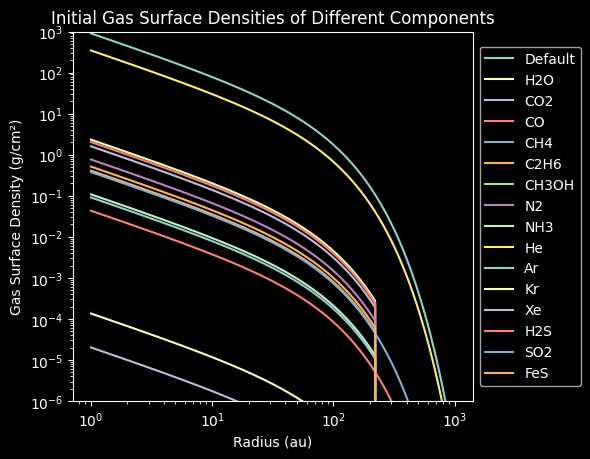

In [ ]:
plt.figure()
plt.title('Initial Gas Surface Densities of Different Components')
for name, comp in sim.components.__dict__.items():
    if(name.startswith("_")):
            continue                            
    if comp.gas._active:
        plt.loglog(sim.grid.r/c.au, comp.gas.Sigma, label=name)

plt.xlabel('Radius (au)')
plt.ylabel('Gas Surface Density (g/cm²)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.subplots_adjust(right=0.75)
plt.ylim(1e-6, 1e3)
plt.show()

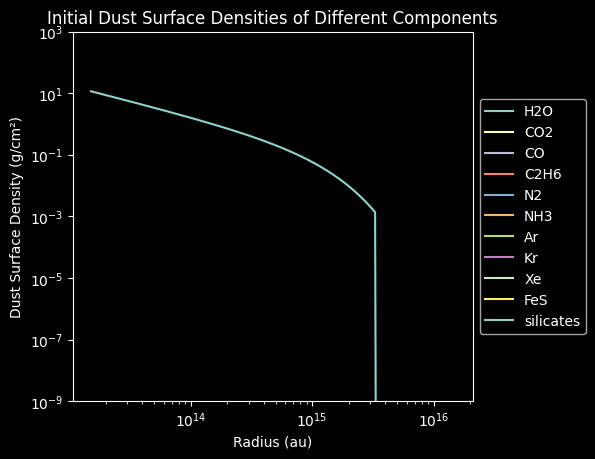

In [7]:
plt.figure()
plt.title('Initial Dust Surface Densities of Different Components')
for name, comp in sim.components.__dict__.items():
    if(name.startswith("_")):
            continue
    if comp.dust._active:
        plt.loglog(sim.grid.r, comp.dust.Sigma.sum(-1), label=name)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.subplots_adjust(right=0.75)
plt.ylim(1e-9, 1e3)
plt.xlabel('Radius (au)')
plt.ylabel('Dust Surface Density (g/cm²)')
plt.show()

In [8]:
sim.writer.datadir = "6_data"
sim.run()


tripodpy v1.0.0

Creating data directory 6_data.
Writing file 6_data\data0000.hdf5
Writing dump file 6_data\frame.dmp
Writing file 6_data\data0001.hdf5
Writing dump file 6_data\frame.dmp
Writing file 6_data\data0002.hdf5
Writing dump file 6_data\frame.dmp
Writing file 6_data\data0003.hdf5
Writing dump file 6_data\frame.dmp
Writing file 6_data\data0004.hdf5
Writing dump file 6_data\frame.dmp
Writing file 6_data\data0005.hdf5
Writing dump file 6_data\frame.dmp
Writing file 6_data\data0006.hdf5
Writing dump file 6_data\frame.dmp
Writing file 6_data\data0007.hdf5
Writing dump file 6_data\frame.dmp
Writing file 6_data\data0008.hdf5
Writing dump file 6_data\frame.dmp
Writing file 6_data\data0009.hdf5
Writing dump file 6_data\frame.dmp
Writing file 6_data\data0010.hdf5
Writing dump file 6_data\frame.dmp
Writing file 6_data\data0011.hdf5
Writing dump file 6_data\frame.dmp
Writing file 6_data\data0012.hdf5
Writing dump file 6_data\frame.dmp
Writing file 6_data\data0013.hdf5
Writing dump file 6

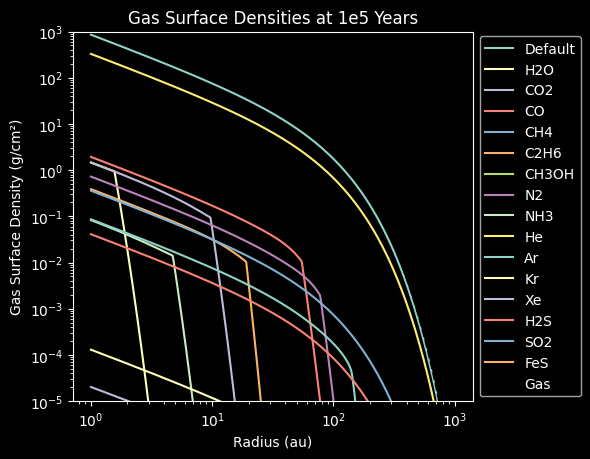

In [9]:
plt.figure()
plt.title('Gas Surface Densities at 1e5 Years')
for name, comp in sim.components.__dict__.items():
    if(name.startswith("_")):
            continue
    if comp.gas._active:
        plt.loglog(sim.grid.r/c.au, comp.gas.Sigma, label=name)

plt.loglog(sim.grid.r/c.au, sim.gas.Sigma, "k--", label="Gas")
plt.xlabel('Radius (au)')
plt.ylabel('Gas Surface Density (g/cm²)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.subplots_adjust(right=0.75)
plt.ylim(1e-5, 1e3)
plt.show()

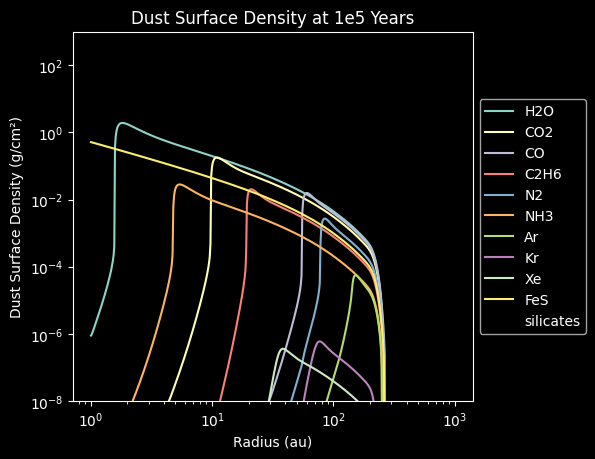

In [10]:
plt.figure()
plt.title('Dust Surface Density at 1e5 Years')
for name, comp in sim.components.__dict__.items():
    if(name.startswith("_") or name=="silicates"):
            continue
    if comp.dust._active:
        plt.loglog(sim.grid.r/c.au, comp.dust.Sigma.sum(-1), label=name)
comp= sim.components.__dict__["silicates"]
plt.loglog(sim.grid.r/c.au, comp.dust.Sigma.sum(-1), "k",label=name)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.subplots_adjust(right=0.75)
plt.ylim(1e-8, 1e3)
plt.xlabel('Radius (au)')
plt.ylabel('Dust Surface Density (g/cm²)')
plt.show()

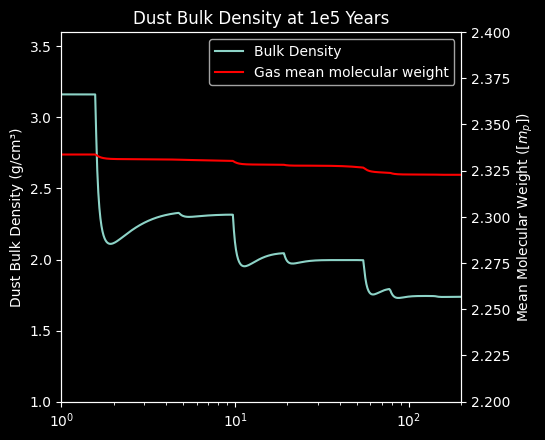

In [11]:
plt.figure()
plt.title('Dust Bulk Density at 1e5 Years')
plt.plot(sim.grid.r/c.au, sim.dust.rhos[:,0], label="Bulk Density")
plt.plot([],[], "r",label="Gas mean molecular weight")
ax = plt.gca()
plt.legend()
ax2 = ax.twinx()
ax2.plot(sim.grid.r/c.au, sim.gas.mu/c.m_p, "r",label="Total Dust")
plt.xscale('log')
plt.subplots_adjust(right=0.75)
plt.xlabel('Radius (au)')
ax.set_ylabel('Dust Bulk Density (g/cm³)')
ax2.set_ylabel('Mean Molecular Weight ([$m_p$])')
ax.set_ylim(1,3.6)
ax2.set_ylim(2.2,2.4)
plt.xlim(1,200)
plt.show()

In [18]:
sim.gas

Group (Gas quantities)
----------------------
    boundary     : Group (Boundary conditions)
    S            : Group (Source terms)
    torque       : Group (Torque parameters)
    v            : Group (Velocities)
  -----
    alpha        : Field (Turbulent alpha parameter)
    cs           : Field (Isothermal sound speed [cm/s])
    eta          : Field (Pressure gradient parameter)
    Fi           : Field (Gas flux interfaces [g/cm/s])
    Hp           : Field (Pressure scale height [cm])
    mfp          : Field (Midplane mean free path [cm])
    mu           : Field (Mean molecular weight [g])
    n            : Field (Miplane number density [1/cm³])
    nu           : Field (Kinematic viscosity [cm²/s])
    P            : Field (Midplane pressure [g/cm/s²])
    rho          : Field (Miplane mass density [g/cm³])
    Sigma        : Field (Surface density [g/cm²])
    SigmaFloor   : Field (Floor value of surface density [g/cm²])
    T            : Field (Temperature [K])
  -----

In [19]:
sim.dust

Group (Dust quantities)
-----------------------
    backreaction : Group (Backreaction coefficients)
    boundary     : Group (Boundary conditions)
    delta        : Group (Mixing parameters)
    f            : Group (Fudge factors)
    Fi           : Group (Fluxes)
    p            : Group (Probabilities)
    q            : Group (Distribution exponents)
    S            : Group (Sources)
    s            : Group (Characteristic particle sizes)
    v            : Group (Velocities)
  -----
    a            : Field (Particle sizes in cm: [a0, fudge * a1, a1, 0.5 * amax, amax])
    D            : Field (Diffusivity [cm²/s])
    eps          : Field (Dust-to-gas ratio)
    fill         : Field (Filling factor)
    H            : Field (Scale heights [cm])
    m            : Field (Particle mass [g])
    qrec         : Field (reconstructed distribution exponent)
    rho          : Field (Midplane mass density per mass bin [g/cm³])
    rhos         : Field (Solid state density [g/cm³])
  

In [38]:
sim.gas.Sigma.shape
sim.dust.Sigma.shape

(500, 2)

In [50]:
def get_snapshot_index(sim, time=None, snap=None):
    t = sim.t.snapshots

    if time is not None:
        # encuentra el índice más cercano
        idx = np.argmin(np.abs(t - time))
        return idx

    if snap is not None:
        if snap < 0:
            return len(t) + snap
        return snap

    return -1  # default

In [81]:
sim.gas.Sigma

[1.18719476e+03 1.17090013e+03 1.15482329e+03 1.13896137e+03
 1.12331153e+03 1.10787099e+03 1.09263697e+03 1.07760676e+03
 1.06277767e+03 1.04814704e+03 1.03371226e+03 1.01947073e+03
 1.00541991e+03 9.91557283e+02 9.77880355e+02 9.64386673e+02
 9.51073817e+02 9.37939396e+02 9.24981049e+02 9.12196448e+02
 8.99583294e+02 8.87139319e+02 8.74862283e+02 8.62749975e+02
 8.50800215e+02 8.39010849e+02 8.27379752e+02 8.15904827e+02
 8.04584004e+02 7.93415237e+02 7.82396507e+02 7.71525815e+02
 7.60801135e+02 7.49990143e+02 7.39294793e+02 7.28790449e+02
 7.18466252e+02 7.08312911e+02 6.98322438e+02 6.88487935e+02
 6.78803418e+02 6.69263664e+02 6.59864090e+02 6.50600648e+02
 6.41469734e+02 6.32468116e+02 6.23592874e+02 6.14841346e+02
 6.06211088e+02 5.97699836e+02 5.89305479e+02 5.81026035e+02
 5.72859628e+02 5.64804475e+02 5.56858870e+02 5.49021173e+02
 5.41289804e+02 5.33663229e+02 5.26139960e+02 5.18718548e+02
 5.11397576e+02 5.04175660e+02 4.97051442e+02 4.90023592e+02
 4.83090803e+02 4.762517

In [58]:
import matplotlib.pyplot as plt
import numpy as np
import dustpy.constants as c

def plot_disk_diagnostics_multicomp(sim, snap=-1, trim_boundary=True, trim_cells=2):
    """
    Genera un dashboard para visualizar un disco en TriPoDPy con múltiples 
    componentes químicos (snowlines, etc).
    """
    r_au = sim.grid.r / c.au
    
    # --- 1. Cálculo Manual de Densidades Totales sumando componentes ---
    # Inicializamos arrays de ceros con la forma de la snapshot elegida
    shape_gas = sim.components.Default.gas.Sigma[snap].shape if sim.components.Default.gas.Sigma.ndim == 2 else sim.components.Default.gas.Sigma.shape
    shape_dust = sim.components.Default.dust.Sigma[snap].shape if sim.components.Default.dust.Sigma.ndim == 3 else sim.components.Default.dust.Sigma.shape
    
    sigma_gas_total = np.zeros(shape_gas[0]) if len(shape_gas) == 1 else np.zeros(shape_gas)
    sigma_dust_total = np.zeros(shape_gas[0]) if len(shape_gas) == 1 else np.zeros(shape_gas) # Queremos el polvo total sumado en masas

    # Sumar todas las componentes de gas activas
    for name, comp in sim.components.__dict__.items():
        if name.startswith("_"): continue
        if comp.gas._active:
            sigma_comp = comp.gas.Sigma[snap] if comp.gas.Sigma.ndim == 2 else comp.gas.Sigma
            sigma_gas_total += sigma_comp
            
    # Sumar todas las componentes de polvo activas
    for name, comp in sim.components.__dict__.items():
        if name.startswith("_"): continue
        if comp.dust._active:
            sigma_comp = comp.dust.Sigma[snap] if comp.dust.Sigma.ndim == 3 else comp.dust.Sigma
            sigma_dust_total += sigma_comp.sum(axis=-1) # Sumamos sobre las masas
            
    # Recalculamos epsilon manualmente
    eps_recalc = sigma_dust_total / sigma_gas_total

    # --- 2. Extracción de las demás variables ---
    eta = sim.gas.eta[snap] if sim.gas.eta.ndim == 2 else sim.gas.eta
    a_max = sim.dust.s.max[snap] if sim.dust.s.max.ndim == 2 else sim.dust.s.max
    
    if sim.dust.St.ndim == 3:
        st_max = sim.dust.St[snap, :, -1]
    else:
        st_max = sim.dust.St[:, -1]

    # --- 3. Recorte de bordes ---
    if trim_boundary and trim_cells > 0:
        r_au = r_au[:-trim_cells]
        sigma_gas_total = sigma_gas_total[:-trim_cells]
        sigma_dust_total = sigma_dust_total[:-trim_cells]
        eps_recalc = eps_recalc[:-trim_cells]
        eta = eta[:-trim_cells]
        a_max = a_max[:-trim_cells]
        st_max = st_max[:-trim_cells]

    # --- 4. Creación de la figura ---
    plt.style.use('dark_background')
    fig, axs = plt.subplots(3, 2, figsize=(14, 15), sharex=True)
    fig.suptitle(f'Diagnóstico Multicomponente (Snapshot: {snap})', fontsize=16, fontweight='bold', color='white')

    # Plot 1: Densidad Superficial Total
    axs[0, 0].loglog(r_au, sigma_gas_total, label='Gas (Suma total)', color='#1f77b4', linewidth=2)
    axs[0, 0].loglog(r_au, sigma_dust_total, label='Polvo (Suma total)', color='#ff7f0e', linewidth=2)
    axs[0, 0].set_ylabel('Densidad Superficial [g/cm²]')
    axs[0, 0].set_title('Densidad Total Recalculada')
    axs[0, 0].grid(True, which="both", ls="--", alpha=0.3)
    axs[0, 0].legend()

    # Plot 2: Parámetro Eta
    axs[0, 1].semilogx(r_au, eta, label='Gradiente de presión ($\eta$)', color='#2ca02c', linewidth=2)
    axs[0, 1].axhline(0, color='white', linestyle='--', linewidth=1, alpha=0.5)
    axs[0, 1].set_ylabel('Parámetro $\eta$')
    axs[0, 1].set_title('Estructura de Presión del Gas')
    axs[0, 1].grid(True, which="both", ls="--", alpha=0.3)
    axs[0, 1].legend()

    # Plot 3: Tamaño Máximo
    axs[1, 0].loglog(r_au, a_max, label='Tamaño máximo ($a_{max}$)', color='#d62728', linewidth=2)
    axs[1, 0].set_ylabel('Tamaño de Partícula [cm]')
    axs[1, 0].set_title('Dinámica del Polvo')
    axs[1, 0].grid(True, which="both", ls="--", alpha=0.3)
    axs[1, 0].legend()

    # Plot 4: Acumulación Relativa (EPSILON RECALCULADO)
    axs[1, 1].loglog(r_au, eps_recalc, label='Razón Polvo/Gas Recalculada ($\epsilon$)', color='#9467bd', linewidth=2)
    # Aquí puedes ver los "saltos" donde las especies de hielo se suman al polvo
    axs[1, 1].axhline(1.0, color='white', linestyle=':', label='Límite $\epsilon = 1$', alpha=0.5)
    axs[1, 1].set_ylabel('$\epsilon$')
    axs[1, 1].set_title('Acumulación Relativa ($\Sigma_{dust} / \Sigma_{gas}$)')
    axs[1, 1].grid(True, which="both", ls="--", alpha=0.3)
    axs[1, 1].legend()

    # Plot 5: Stokes
    axs[2, 0].loglog(r_au, st_max, label='Stokes de $a_{max}$', color='#e377c2', linewidth=2)
    axs[2, 0].axhline(1.0, color='white', linestyle=':', alpha=0.5)
    axs[2, 0].set_ylabel('Número de Stokes ($St$)')
    axs[2, 0].set_xlabel('Radio [AU]')
    axs[2, 0].set_title('Acoplamiento Aerodinámico')
    axs[2, 0].grid(True, which="both", ls="--", alpha=0.3)
    axs[2, 0].legend()

    axs[2, 1].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.94) 
    plt.show()
    plt.style.use('default')

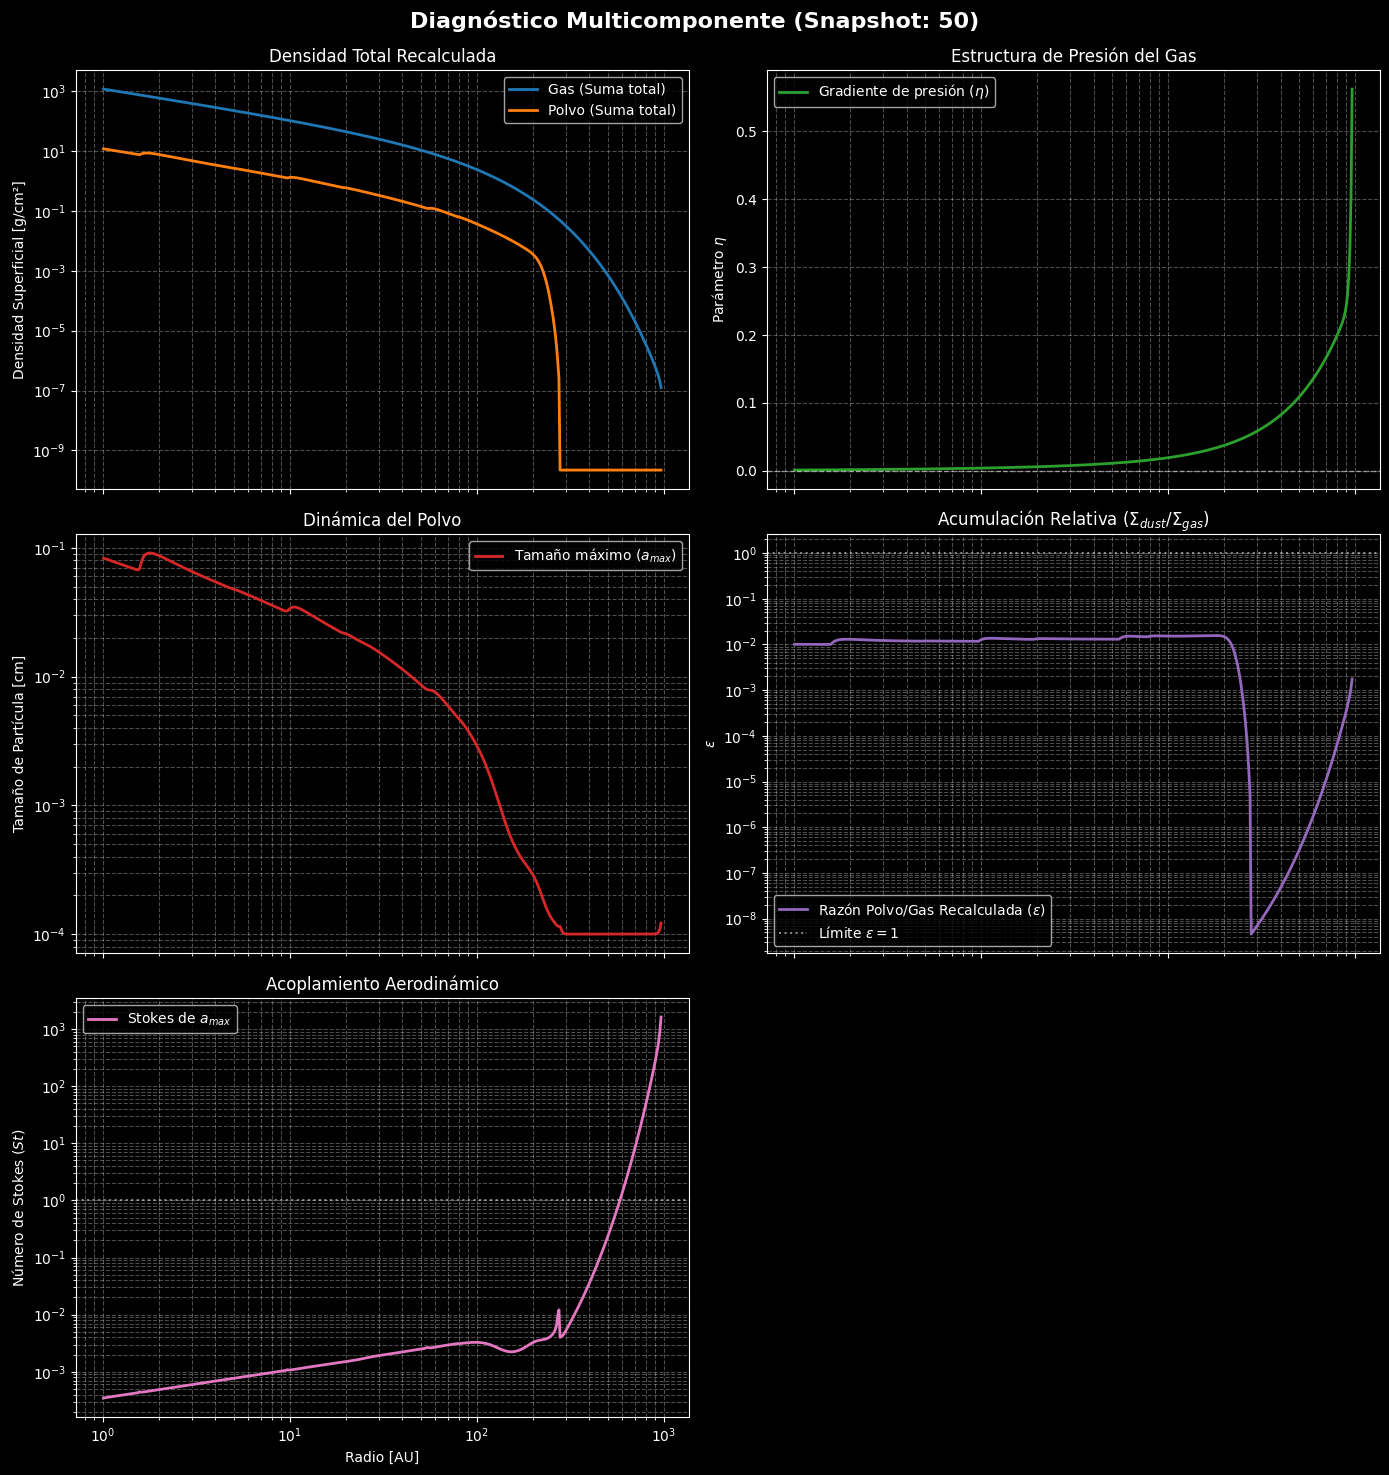

In [ ]:
plot_disk_diagnostics_multicomp(sim, snap=)

AttributeError: 'numpy.ndarray' object has no attribute 't'